In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score, roc_curve)
from sklearn.preprocessing import LabelEncoder
import joblib
import os

os.makedirs('../plots', exist_ok=True)
os.makedirs('../models', exist_ok=True)
sns.set_theme(style="whitegrid")

In [2]:
df = pd.read_csv('../data/credit_risk_dataset.csv')
print(f"Shape: {df.shape}")
print(f"\nColumns:\n{df.columns.tolist()}")
df.head()

Shape: (32581, 12)

Columns:
['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_status', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']


,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
print(df.info())
print("\n--- Descriptive Statistics ---")
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  str    
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  str    
 5   loan_grade                  32581 non-null  str    
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  str    
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), str(4)
memory usage: 3.0 MB
None

--- Descriptive Statistics ---


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [4]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Percent %': missing_pct})
print(missing_df[missing_df['Missing'] > 0])

print(f"\nClass distribution:")
print(df['loan_status'].value_counts())
print(f"\nDefault rate: {df['loan_status'].mean():.2%}")

                   Missing  Percent %
person_emp_length      895       2.75
loan_int_rate         3116       9.56

Class distribution:
loan_status
0    25473
1     7108
Name: count, dtype: int64

Default rate: 21.82%


In [5]:
# Удаляем выбросы по возрасту (> 100 лет)
df = df[df['person_age'] < 100]

# Удаляем выбросы по стажу (> 60 лет)
df = df[df['person_emp_length'] < 60]

# Заполняем пропуски медианой
df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)
df['person_emp_length'].fillna(df['person_emp_length'].median(), inplace=True)

print(f"Shape after cleaning: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")

Shape after cleaning: (31679, 12)
Missing values: 3047


C:\Users\kakad\AppData\Local\Temp\ipykernel_27708\1160424173.py:8: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['loan_int_rate'].fillna(df['loan_int_rate'].median(), inplace=True)
C:\Users\kakad\AppData\Local\Temp\ipykernel_27708\1160424173.py:9: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series thro

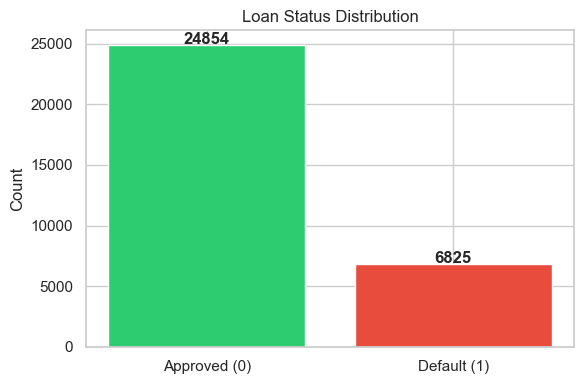

Default rate: 21.54%


In [6]:
plt.figure(figsize=(6, 4))
counts = df['loan_status'].value_counts()
colors = ['#2ecc71', '#e74c3c']
plt.bar(['Approved (0)', 'Default (1)'], counts.values, color=colors)
plt.title('Loan Status Distribution')
plt.ylabel('Count')
for i, v in enumerate(counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')
plt.tight_layout()
plt.savefig('../plots/class_distribution.png', dpi=150)
plt.show()
print(f"Default rate: {df['loan_status'].mean():.2%}")

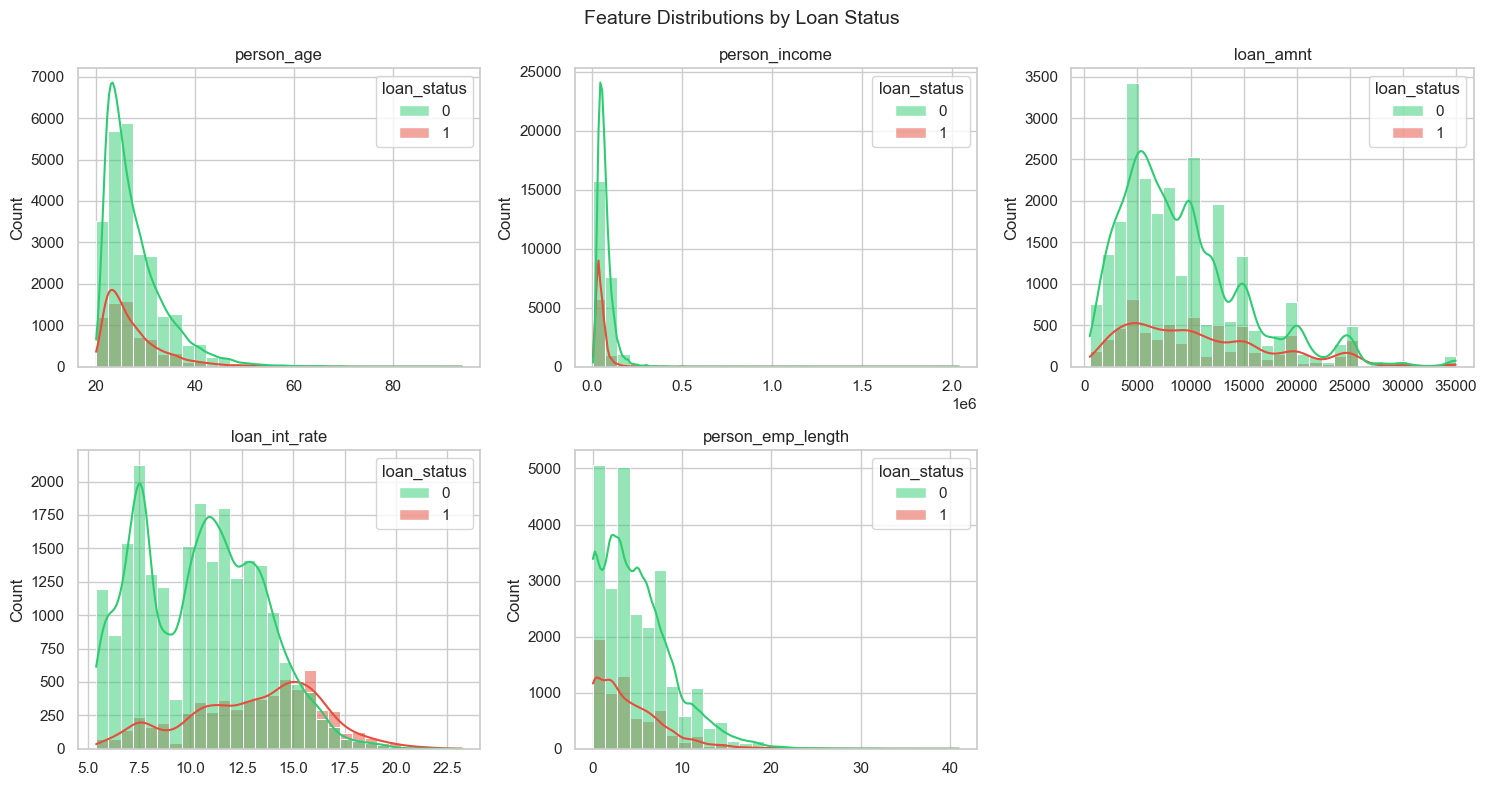

In [7]:
num_features = ['person_age', 'person_income', 'loan_amnt', 'loan_int_rate', 'person_emp_length']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(num_features):
    sns.histplot(data=df, x=feat, hue='loan_status',
                 palette={0: '#2ecc71', 1: '#e74c3c'},
                 ax=axes[i], kde=True, bins=30)
    axes[i].set_title(feat)
    axes[i].set_xlabel('')

axes[-1].set_visible(False)
plt.suptitle('Feature Distributions by Loan Status', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/feature_distributions.png', dpi=150)
plt.show()

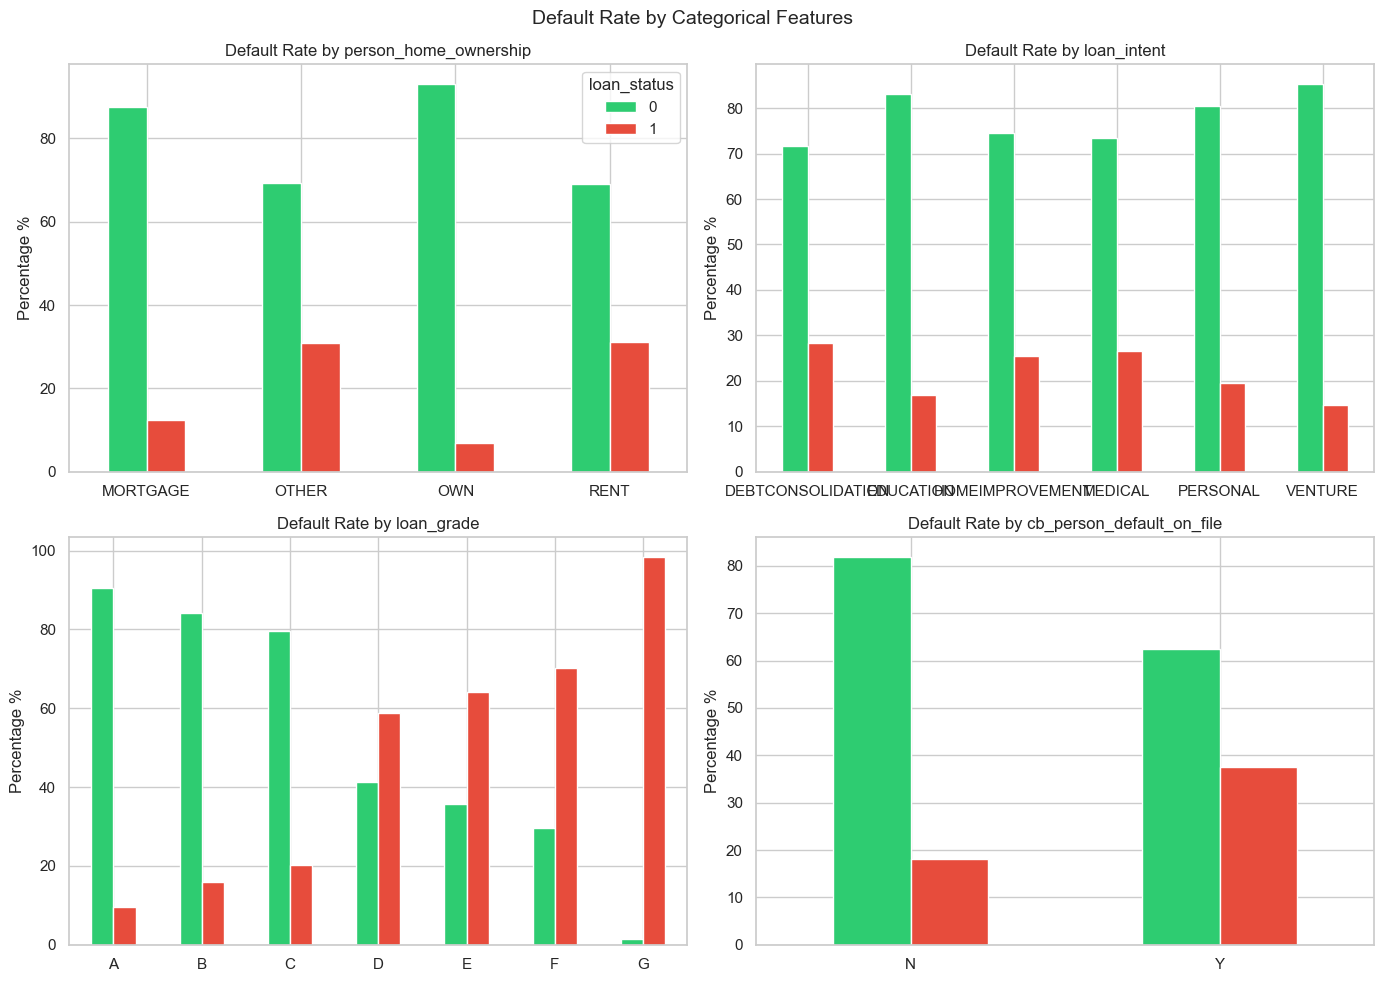

In [8]:
cat_features = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(cat_features):
    ct = pd.crosstab(df[feat], df['loan_status'], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[i], color=['#2ecc71', '#e74c3c'],
            rot=0, legend=(i == 0))
    axes[i].set_title(f'Default Rate by {feat}')
    axes[i].set_ylabel('Percentage %')
    axes[i].set_xlabel('')

plt.suptitle('Default Rate by Categorical Features', fontsize=14)
plt.tight_layout()
plt.savefig('../plots/categorical_features.png', dpi=150)
plt.show()

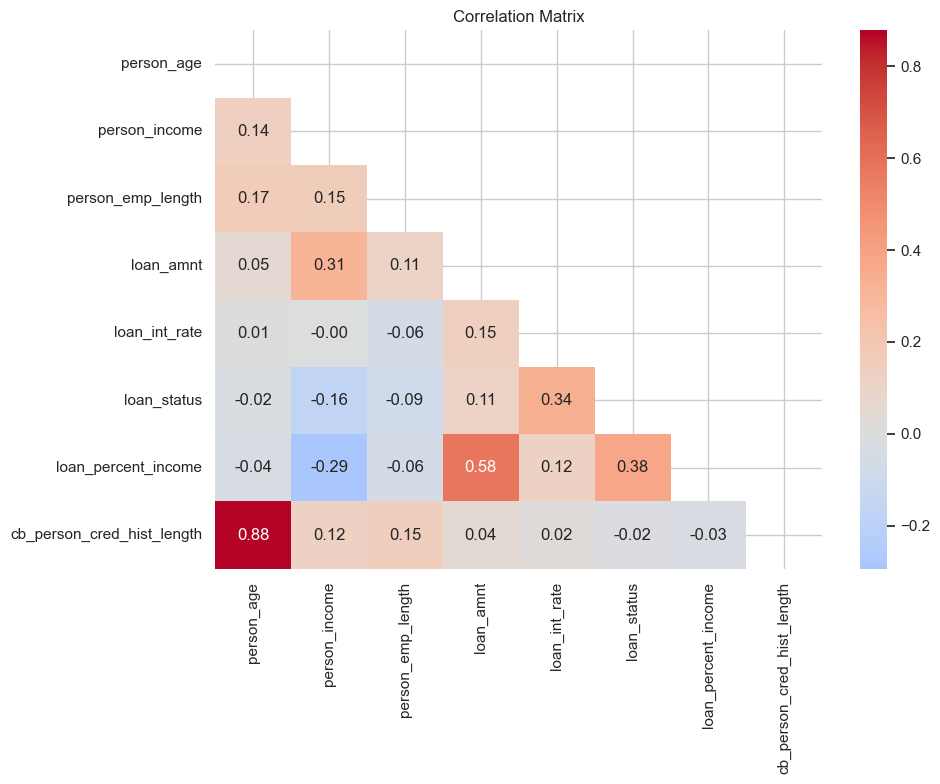

In [9]:
plt.figure(figsize=(10, 8))
corr = df.select_dtypes(include=np.number).corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, mask=mask)
plt.title('Correlation Matrix')
plt.tight_layout()
plt.savefig('../plots/correlation_matrix.png', dpi=150)
plt.show()

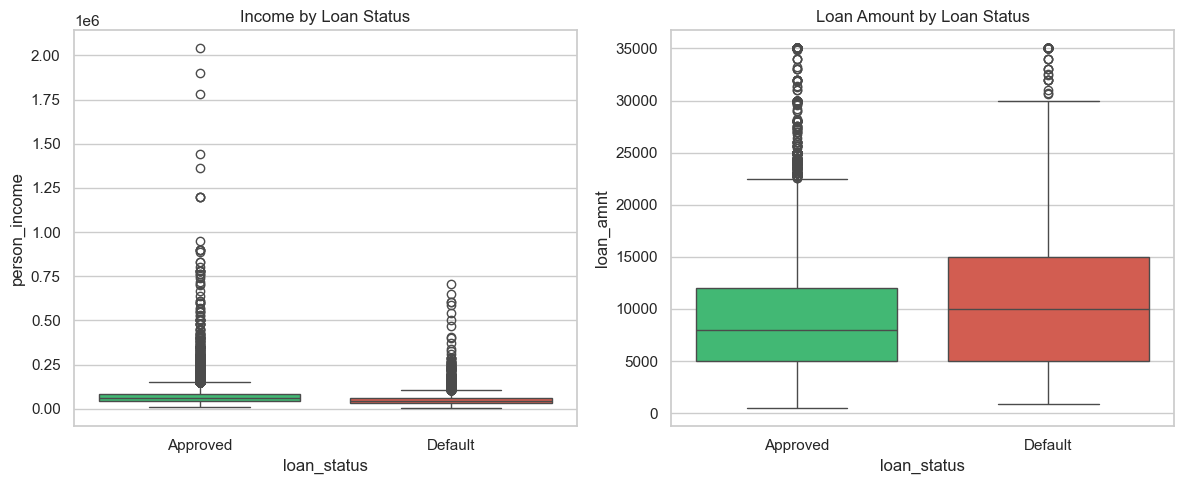

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.boxplot(data=df, x='loan_status', y='person_income',
            hue='loan_status', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=axes[0])
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Approved', 'Default'])
axes[0].set_title('Income by Loan Status')

sns.boxplot(data=df, x='loan_status', y='loan_amnt',
            hue='loan_status', palette=['#2ecc71', '#e74c3c'],
            legend=False, ax=axes[1])
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Approved', 'Default'])
axes[1].set_title('Loan Amount by Loan Status')

plt.tight_layout()
plt.savefig('../plots/boxplot_features.png', dpi=150)
plt.show()

In [20]:
df_ml = df.copy()

# Encode categorical features
cat_cols = ['person_home_ownership', 'loan_intent', 'loan_grade', 'cb_person_default_on_file']
label_encoders = {}

for col in cat_cols:
    le = LabelEncoder()
    df_ml[col] = le.fit_transform(df_ml[col])
    label_encoders[col] = le
    print(f"{col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

X = df_ml.drop(columns=['loan_status'])
y = df_ml['loan_status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain: {X_train.shape}, Test: {X_test.shape}")
print(f"Default rate in train: {y_train.mean():.2%}")
print(f"Default rate in test:  {y_test.mean():.2%}")

person_home_ownership: {'MORTGAGE': np.int64(0), 'OTHER': np.int64(1), 'OWN': np.int64(2), 'RENT': np.int64(3)}
loan_intent: {'DEBTCONSOLIDATION': np.int64(0), 'EDUCATION': np.int64(1), 'HOMEIMPROVEMENT': np.int64(2), 'MEDICAL': np.int64(3), 'PERSONAL': np.int64(4), 'VENTURE': np.int64(5)}
loan_grade: {'A': np.int64(0), 'B': np.int64(1), 'C': np.int64(2), 'D': np.int64(3), 'E': np.int64(4), 'F': np.int64(5), 'G': np.int64(6)}
cb_person_default_on_file: {'N': np.int64(0), 'Y': np.int64(1)}

Train: (25343, 11), Test: (6336, 11)
Default rate in train: 21.54%
Default rate in test:  21.54%


In [21]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    oob_score=True,
    n_jobs=-1
)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
y_proba = rf.predict_proba(X_test)[:, 1]

print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}")
print(f"OOB Score: {rf.oob_score_:.4f}")
print()
print(classification_report(y_test, y_pred, target_names=['Approved', 'Default']))

Accuracy:  0.9350
ROC-AUC:   0.9375
OOB Score: 0.9301

              precision    recall  f1-score   support

    Approved       0.93      0.99      0.96      4971
     Default       0.97      0.72      0.83      1365

    accuracy                           0.93      6336
   macro avg       0.95      0.86      0.89      6336
weighted avg       0.94      0.93      0.93      6336



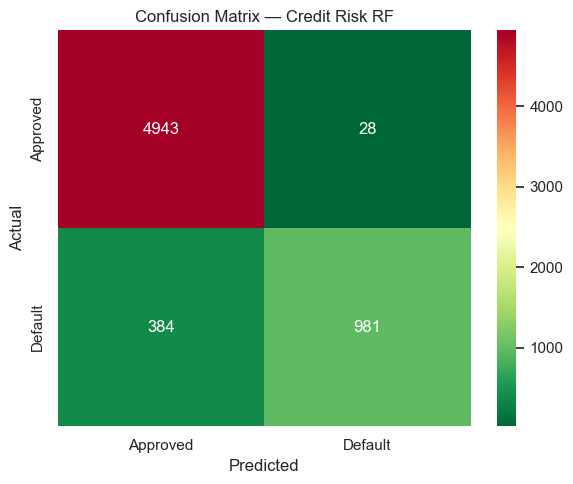

In [22]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn_r',
            xticklabels=['Approved', 'Default'],
            yticklabels=['Approved', 'Default'])
plt.title('Confusion Matrix — Credit Risk RF')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('../plots/confusion_matrix.png', dpi=150)
plt.show()

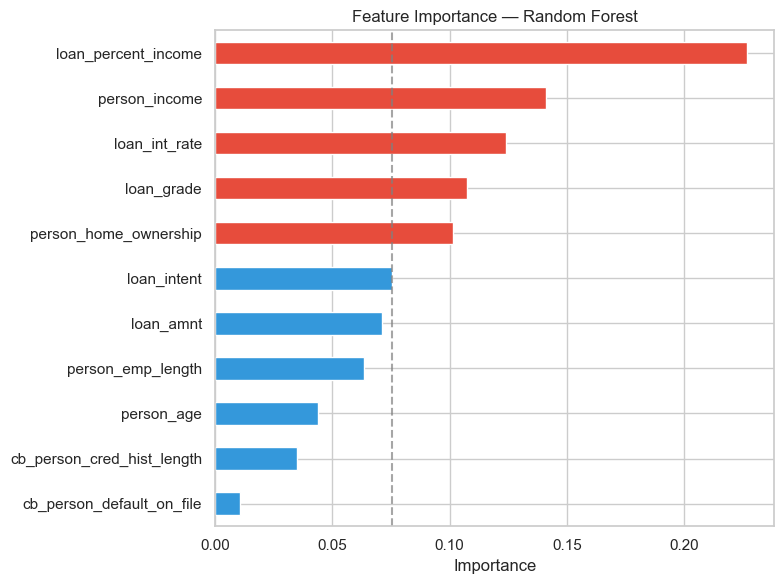

In [23]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
importances = importances.sort_values(ascending=True)

plt.figure(figsize=(8, 6))
colors = ['#e74c3c' if v > importances.median() else '#3498db'
          for v in importances.values]
importances.plot(kind='barh', color=colors)
plt.title('Feature Importance — Random Forest')
plt.xlabel('Importance')
plt.axvline(importances.median(), color='gray', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.savefig('../plots/feature_importance.png', dpi=150)
plt.show()

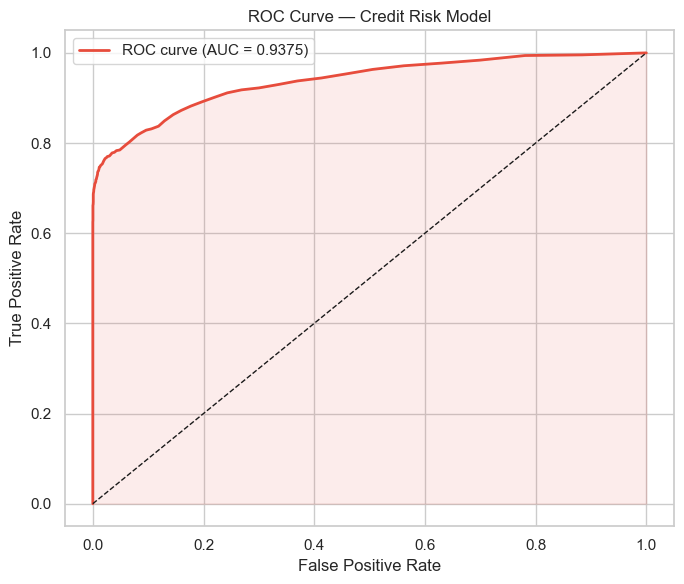

In [24]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='#e74c3c', lw=2, label=f'ROC curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], 'k--', lw=1)
plt.fill_between(fpr, tpr, alpha=0.1, color='#e74c3c')
plt.title('ROC Curve — Credit Risk Model')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/roc_curve.png', dpi=150)
plt.show()

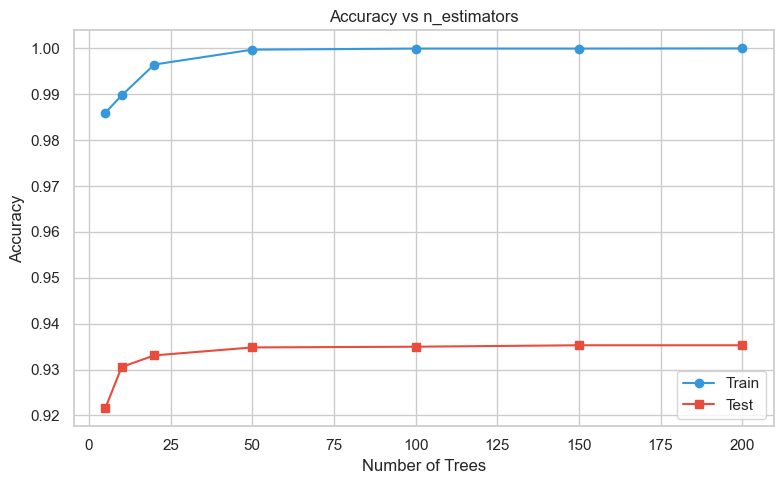

In [25]:
n_estimators_range = [5, 10, 20, 50, 100, 150, 200]
train_scores, test_scores = [], []

for n in n_estimators_range:
    model = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.figure(figsize=(8, 5))
plt.plot(n_estimators_range, train_scores, marker='o', label='Train', color='#3498db')
plt.plot(n_estimators_range, test_scores, marker='s', label='Test', color='#e74c3c')
plt.title('Accuracy vs n_estimators')
plt.xlabel('Number of Trees')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.savefig('../plots/learning_curve.png', dpi=150)
plt.show()

In [26]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10]
}

grid_search = GridSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_grid, cv=5, scoring='roc_auc',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print(f"Best params:   {grid_search.best_params_}")
print(f"Best CV AUC:   {grid_search.best_score_:.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, grid_search.predict(X_test)):.4f}")
print(f"Test AUC:      {roc_auc_score(y_test, grid_search.predict_proba(X_test)[:, 1]):.4f}")

Fitting 5 folds for each of 36 candidates, totalling 180 fits
Best params:   {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Best CV AUC:   0.9296
Test Accuracy: 0.9353
Test AUC:      0.9385


In [18]:
joblib.dump(rf, '../models/rf_model.pkl')
joblib.dump(label_encoders, '../models/label_encoders.pkl')
joblib.dump(X.columns.tolist(), '../models/feature_names.pkl')

print("✅ Model saved!")
print(f"Features: {X.columns.tolist()}")

✅ Model saved!
Features: ['person_age', 'person_income', 'person_home_ownership', 'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt', 'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file', 'cb_person_cred_hist_length']
